In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report,roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelBinarizer

## 유방암 데이터 로드

In [ ]:
#cancer = datasets.load_breast_cancer()
cancer = pd.read_csv('data/Data.csv',engine="python")

In [ ]:
#print(cancer.DESCR)

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

    :Number of Instances: 569

    :Number of Attributes: 30 numeric, predictive attributes and the class

    :Attribute Information:
        - radius (mean of distances from center to points on the perimeter)
        - texture (standard deviation of gray-scale values)
        - perimeter
        - area
        - smoothness (local variation in radius lengths)
        - compactness (perimeter^2 / area - 1.0)
        - concavity (severity of concave portions of the contour)
        - concave points (number of concave portions of the contour)
        - symmetry
        - fractal dimension ("coastline approximation" - 1)

        The mean, standard error, and "worst" or largest (mean of the three
        worst/largest values) of these features were computed for each image,
        resulting in 30 features.  For instance, field 0 is Mean Radi

## 데이터 전처리

In [ ]:
data_x = pd.DataFrame(cancer['data'], columns=cancer['feature_names'])

In [ ]:
data_x

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [ ]:
sns.set(rc = {'figure.figsize':(40,40)})
sns.set(font_scale=2)
sns.heatmap(data=data_x.corr(), square=True, annot=True, cbar=True)
plt.show()
sns.reset_defaults()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
data_y = cancer['target']

In [ ]:
train_x, test_x, train_y, test_y=train_test_split(data_x,data_y,test_size=0.2, shuffle=True,stratify=data_y)
print(train_x.shape, train_y.shape)
print(test_x.shape, test_y.shape)

(455, 30) (455,)
(114, 30) (114,)


## Support Vector Machine 학습

In [ ]:
SVM = SVC(probability=True)
SVM.fit(train_x, train_y)

SVC(probability=True)

## 학습 검증

In [ ]:
SVM_proba = SVM.predict_proba(test_x)[:,-1]
SVM_pred = SVM.predict(test_x)

dftest = pd.DataFrame(np.column_stack([SVM_pred,test_y]),columns=['predict','true'])
dftest['probability'] = list(np.round(SVM_proba,3))

dftest

,predict,true,probability
0,1,0,0.588
1,0,0,0.003
2,0,0,0.001
3,1,1,0.983
4,1,1,0.956
...,...,...,...
109,1,0,0.793
110,1,1,0.962
111,0,0,0.010
112,1,1,0.964


In [ ]:
print(classification_report(test_y,SVM_pred,target_names=cancer.target_names))

tn, fp, fn, tp = confusion_matrix(test_y, SVM_pred).ravel()
print("tn = {} fp = {} fn = {} tp = {}".format(tn, fp, fn, tp))

              precision    recall  f1-score   support

   malignant       1.00      0.88      0.94        42
      benign       0.94      1.00      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.94      0.95       114
weighted avg       0.96      0.96      0.96       114

tn = 37 fp = 5 fn = 0 tp = 72


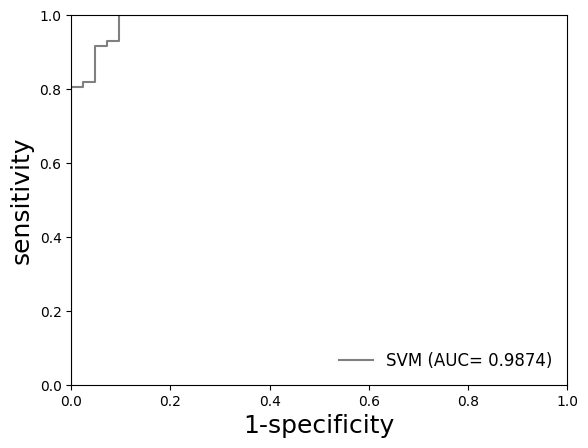

In [ ]:
fpr_SVM, tpr_SVM, _ = roc_curve(test_y, SVM_proba)
auc_SVM = auc(fpr_SVM, tpr_SVM)

plt.figure(dpi=100, facecolor='white')
rcParams['font.family'] = "Times New Roman"
rcParams["legend.facecolor"] = 'white'
rcParams["legend.edgecolor"] = 'white'
plt.plot(fpr_SVM, tpr_SVM, label="SVM (AUC= %.4f)" % (round(auc_SVM, 4)),color='gray',linestyle='solid')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('1-specificity', fontsize=18)
plt.ylabel('sensitivity', fontsize=18)
plt.legend(loc="lower right", fontsize=12)
plt.show()

## XGBoost 학습

In [ ]:
XGB = XGBClassifier()
XGB.fit(train_x, train_y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

## 학습 검증

In [ ]:
XGB_proba = XGB.predict_proba(test_x)[:,-1]
XGB_pred = XGB.predict(test_x)

dftest = pd.DataFrame(np.column_stack([XGB_pred,test_y]),columns=['predict','true'])
dftest['probability'] = list(np.round(XGB_proba,3))

dftest

,predict,true,probability
0,0,0,0.000
1,0,0,0.000
2,0,0,0.000
3,1,1,0.999
4,1,1,0.999
...,...,...,...
109,1,0,0.570
110,1,1,1.000
111,0,0,0.000
112,1,1,1.000


In [ ]:
tn, fp, fn, tp = confusion_matrix(test_y, XGB_pred).ravel()
print("tn = {}\t fp = {}\t fn = {}\t tp = {}".format(tn, fp, fn, tp))
print("==========================================================")
print(classification_report(test_y,XGB_pred,target_names=cancer.target_names))

tn = 41	 fp = 1	 fn = 2	 tp = 70
              precision    recall  f1-score   support

   malignant       0.95      0.98      0.96        42
      benign       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



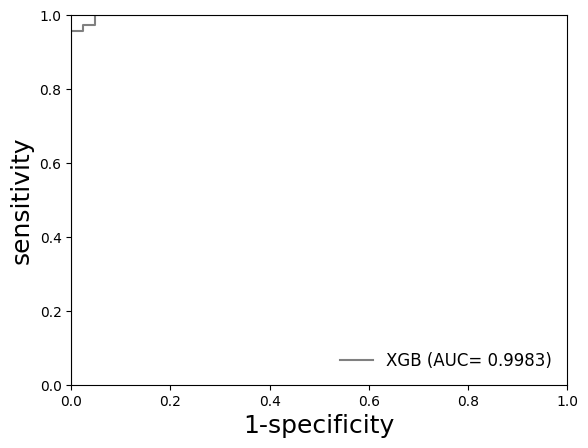

In [ ]:
fpr_XGB, tpr_XGB, _ = roc_curve(test_y, XGB_proba)
auc_XGB = auc(fpr_XGB, tpr_XGB)

plt.figure(dpi=100, facecolor='white')
rcParams['font.family'] = "Times New Roman"
rcParams["legend.facecolor"] = 'white'
rcParams["legend.edgecolor"] = 'white'
plt.plot(fpr_XGB, tpr_XGB, label="XGB (AUC= %.4f)" % (round(auc_XGB, 4)),color='gray',linestyle='solid')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('1-specificity', fontsize=18)
plt.ylabel('sensitivity', fontsize=18)
plt.legend(loc="lower right", fontsize=12)
plt.show()

## Random Forest 학습

In [ ]:
RF = RandomForestClassifier()
RF.fit(train_x, train_y)

RandomForestClassifier()

## 학습 검증

In [ ]:
RF_proba = RF.predict_proba(test_x)[:,-1]
RF_pred = RF.predict(test_x)

dftest = pd.DataFrame(np.column_stack([RF_pred,test_y]),columns=['predict','true'])
dftest['probability'] = list(np.round(RF_proba,3))

dftest

,predict,true,probability
0,0,0,0.05
1,0,0,0.00
2,0,0,0.00
3,1,1,0.98
4,1,1,1.00
...,...,...,...
109,1,0,0.76
110,1,1,1.00
111,0,0,0.00
112,1,1,1.00


In [ ]:
tn, fp, fn, tp = confusion_matrix(test_y, RF_pred).ravel()
print("tn = {}\t fp = {}\t fn = {}\t tp = {}".format(tn, fp, fn, tp))
print("==========================================================")
print(classification_report(test_y,RF_pred,target_names=cancer.target_names))

tn = 40	 fp = 2	 fn = 1	 tp = 71
              precision    recall  f1-score   support

   malignant       0.98      0.95      0.96        42
      benign       0.97      0.99      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



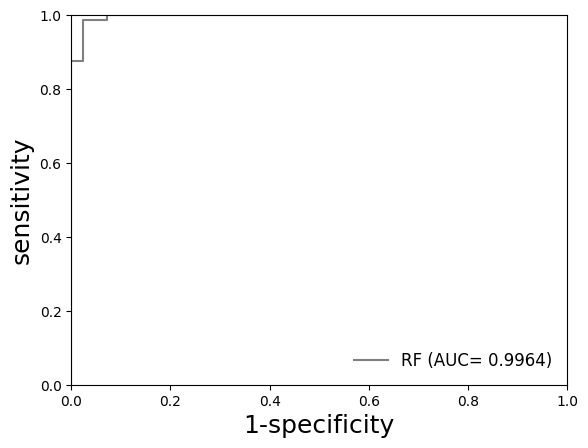

In [ ]:
fpr_RF, tpr_RF, _ = roc_curve(test_y, RF_proba)
auc_RF = auc(fpr_RF, tpr_RF)

plt.figure(dpi=100, facecolor='white')
rcParams['font.family'] = "Times New Roman"
rcParams["legend.facecolor"] = 'white'
rcParams["legend.edgecolor"] = 'white'
plt.plot(fpr_RF, tpr_RF, label="RF (AUC= %.4f)" % (round(auc_RF, 4)),color='gray',linestyle='solid')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('1-specificity', fontsize=18)
plt.ylabel('sensitivity', fontsize=18)
plt.legend(loc="lower right", fontsize=12)
plt.show()